# GoPreaux Example

In this notebook we look at how we can import and use models from [GoPreaux (caat)](https://github.com/crpellegrino/gopreaux), a package for using multi-dimensional Gaussian Process Regression to simulate extragalactic astronomical transient light curves.  This model requires that the GoPreaux (caat) package is installed. Currently GoPreaux is not available on PyPI, so users will need to install it from source from https://github.com/crpellegrino/gopreaux.

**Dependency Conflicts:**

There is a version conflict with numpy between GoPreaux and LightCurveLynx, but this does not impact
the functions we need. Users can install GoPreaux first and then install LightCurveLynx (upgrading all
dependencies). You will still get errors about the version requirements for caat, but they can be ignored.

## Load a GoPreaux Model

LightCurveLynx's GoPreaux wrapper uses pretrained models that GoPreaux stores in fits files. Users can find these models at: https://github.com/crpellegrino/gopreaux/tree/main/data/final_models. This notebook requires you to download the files, save them to a local directory, and update the `filename` variable to point to the file.

In [1]:
from caat import SNModel
from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR

filename = _LIGHTCURVELYNX_BASE_DATA_DIR / "model_files" / "SESNe_SNIIb_GP_model.fits"
gp_model = SNModel(str(filename))

No Kernel, need to implement


GoPreaux models the rest frame SED as a function of phase. Zero phase corresponds to the peak spectral flux density at 5500 Å, chosen to be close to the effective wavelengths of the *V* and *r* passbands. In practice, GoPreaux provides a change in flux relative to the peak at 5500 Å, in magnitude units: `2.5 lg(flux) + peak_mag5500`. Therefore, to fully simulate a light curve, we provide both the GoPreaux model and the corresponding peak magnitude in the rest frame. Please note, that `peak_mag5500` would correspond to the observer frame's flux density of `mag2flux(peak_mag5500) * (1 + redshift)` observed at `5500 Å * (1 + redshift)`, see [`rest_to_obs_flux` function](https://lightcurvelynx.readthedocs.io/en/latest/autoapi/lightcurvelynx/astro_utils/redshift/index.html#lightcurvelynx.astro_utils.redshift.rest_to_obs_flux).

In [2]:
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.models.gopreaux_models import GoPreauxModel
from lightcurvelynx.utils.extrapolate import LastValue

# Sample the peak magnitude at 5500 angstroms uniformly between 17 and 20.
magnitude_sampler = NumpyRandomFunc("uniform", low=17, high=20)
survey_start = 60676.0
survey_end = survey_start + 50.0

model = GoPreauxModel(
    gp_model,
    peak_mag5500=magnitude_sampler,
    # Standard attributes for all physical objects, set all to constants
    # for this example.
    ra=45.0,
    dec=-20.0,
    redshift=1e-10,  # Set to a very small value to avoid issues with zero redshift.
    t0=survey_start + 15.0,  # Peak is 15 days after the start of the survey.
    node_label="source",
    time_extrapolation=LastValue(),
    wave_extrapolation=LastValue(),
)

The model will automatically use the bounds defined by the underlying gopreaux model.

In [3]:
print(f"Wavelengths Bounds (angstroms): [{model.minwave()}, {model.maxwave()}]")
print(f"Phases Bounds (days): [{model.minphase()}, {model.maxphase()}]")

Wavelengths Bounds (angstroms): [1530.0000000001003, 22115.22849241136]
Phases Bounds (days): [-19.9999999999, 49.958333333235316]


## Create the Survey Data

We create fake survey data that will focus on a single patch of the sky so we can see how the model evolves. In most cases, we will want to load this information from actual observing files.

In this example we will use the default Rubin passbands. We create a fake cadence that observes the exact same location on the sky (45.0, -20.0) three times a night, once in each of the "r", "g", and "i" bands. This is not particularly realistic for a survey, but it provides densely sampled output curves for the purpose of this notebook.

Note that we specify a lot of noise parameters with the fake `OpSim`, but in normal cases users will be loading a predefined opsim with all of that information pre-populated.

In [4]:
import numpy as np

from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.obstable.opsim import OpSim

# Load the default LSST passbands.
passband_group = PassbandGroup.from_preset(preset="LSST")

filters = ["g", "r", "i"]
num_samples = 50
survey_data = {
    "observationStartMJD": np.linspace(survey_start, survey_end, num_samples),
    "fieldRA": np.full(num_samples, 45.0),
    "fieldDec": np.full(num_samples, -20.0),
    "zp_nJy": np.random.normal(loc=1.0, scale=0.1, size=num_samples),
    "filter": [filters[i % 3] for i in range(num_samples)],
    "seeing": np.random.normal(loc=1.1, scale=0.1, size=num_samples),
    "skybrightness": np.random.normal(loc=25.0, scale=0.1, size=num_samples),
    "exptime": np.full(num_samples, 30.0),
}
obs_table = OpSim(survey_data)

INFO:lightcurvelynx.astro_utils.passbands:Loading passbands from preset LSST
INFO:lightcurvelynx.utils.data_download:Data file /Users/jkubica/.cache/lightcurvelynx/passbands/LSST/u.dat already exists. Skipping download.
INFO:lightcurvelynx.astro_utils.passbands:Loading passband from file: /Users/jkubica/.cache/lightcurvelynx/passbands/LSST/u.dat
INFO:lightcurvelynx.utils.data_download:Data file /Users/jkubica/.cache/lightcurvelynx/passbands/LSST/g.dat already exists. Skipping download.
INFO:lightcurvelynx.astro_utils.passbands:Loading passband from file: /Users/jkubica/.cache/lightcurvelynx/passbands/LSST/g.dat
INFO:lightcurvelynx.utils.data_download:Data file /Users/jkubica/.cache/lightcurvelynx/passbands/LSST/r.dat already exists. Skipping download.
INFO:lightcurvelynx.astro_utils.passbands:Loading passband from file: /Users/jkubica/.cache/lightcurvelynx/passbands/LSST/r.dat
INFO:lightcurvelynx.utils.data_download:Data file /Users/jkubica/.cache/lightcurvelynx/passbands/LSST/i.dat al

## Generate the simulations

We can now generate random simulations with all the information defined above. The `simulate_lightcurves` function takes four parameters: the source from which we want to sample (here the collection of lightcurves), the number of results to simulate (10), the opsim, and the passband information.

In [5]:
from lightcurvelynx.simulate import simulate_lightcurves

lightcurves = simulate_lightcurves(
    model,
    10,
    obs_table,
    passband_group,
)

INFO:lightcurvelynx.simulate:Starting batch at 0 with 10 samples.
INFO:lightcurvelynx.simulate:Sampling 10 parameter sets from the model.
INFO:lightcurvelynx.simulate:Setting up result data structures.
INFO:lightcurvelynx.simulate:Performing range searches to find matching observations.
INFO:lightcurvelynx.simulate:Simulating light curves for each object.
Simulating: 100%|██████████| 10/10 [00:00<00:00, 10.00obj/s]
INFO:lightcurvelynx.simulate:Compiling results.


The results are written in the [nested-pandas](https://nested-pandas.readthedocs.io) format for easy analysis. Each row corresponds to a single simulated object, with a unique id, ra, dec, etc. The column `params` include all internal state, including hyperparameter settings, that was used to generate this object. The nested `lightcurve` column contains the times, filters, and fluxes for each observation of that object.  We can treat it as a (nested) table.

Let's look at the lightcurve for the first object sampled:

In [6]:
print(lightcurves.loc[0]["lightcurve"])

             mjd filter          flux     fluxerr  flux_perfect  survey_idx  \
0   60676.000000      g  30936.785858  195.859142  30819.979380           0   
1   60677.020408      r  60581.438682  256.040454  60763.720197           0   
..           ...    ...           ...         ...           ...         ...   
48  60724.979592      g  15704.380615  129.148986  15710.045387           0   
49  60726.000000      r  40958.643648  233.145156  41719.724545           0   

    obs_idx  is_saturated  
0         0         False  
1         1         False  
..      ...           ...  
48       48         False  
49       49         False  

[50 rows x 8 columns]


Let's plot the first few lightcurves to see what they look like when observed via Rubin's cadence. We plot the results in magnitudes to be consistent with EZTaoX outputs. However note that our error bars can be huge for small fluxes (and this is something we need to fix). 

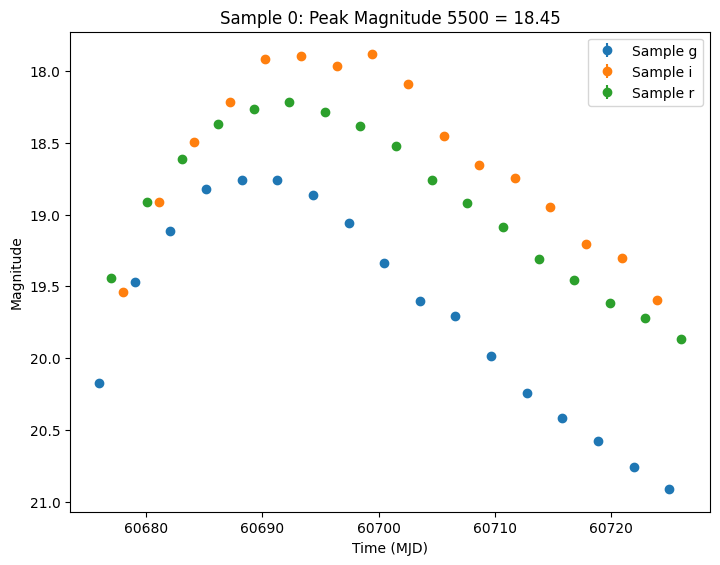

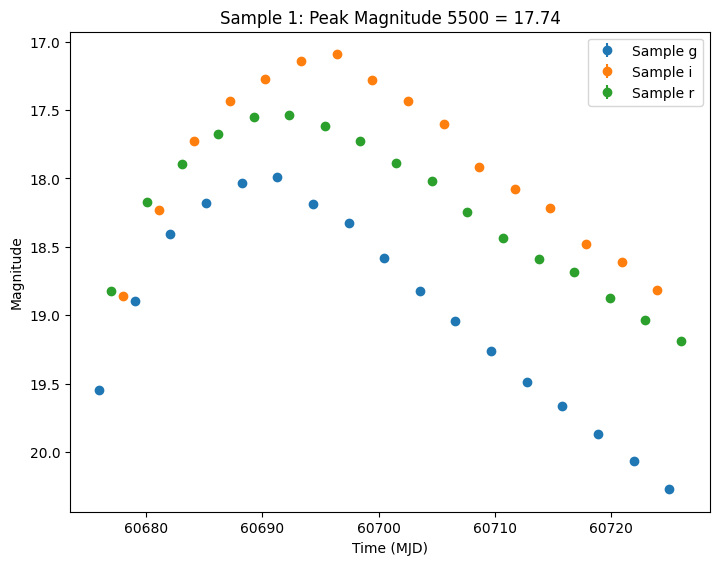

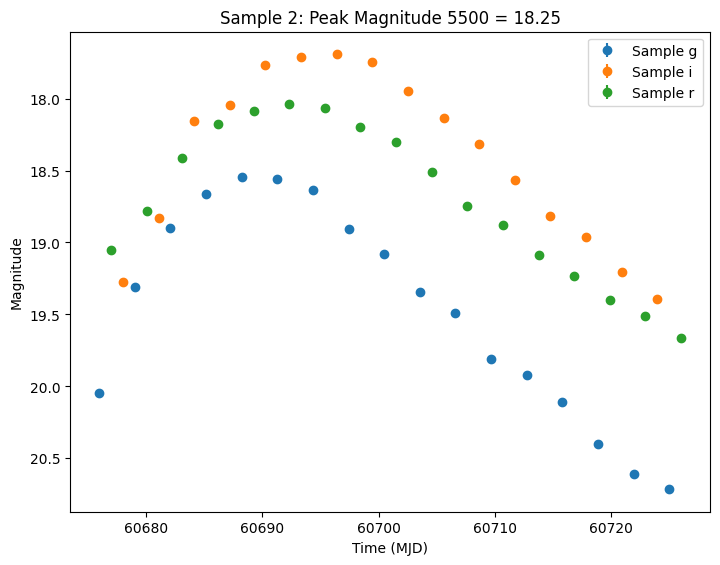

In [7]:
import matplotlib.pyplot as plt
from lightcurvelynx.utils.plotting import plot_lightcurves

for idx in range(3):
    # Extract the row for this object.
    lc = lightcurves.loc[idx]

    if lc["nobs"] == 0:
        continue

    # Unpack the nested columns (filters, mjd, flux, and flux error).
    lc_filters = np.asarray(lc["lightcurve"]["filter"], dtype=str)
    lc_mjd = np.asarray(lc["lightcurve"]["mjd"], dtype=float)
    lc_flux = np.asarray(lc["lightcurve"]["flux"], dtype=float)
    lc_fluxerr = np.asarray(lc["lightcurve"]["fluxerr"], dtype=float)

    # Get the peak magnitude for the title.
    peak_mag = lc["params"]["source.peak_mag5500"]

    # Plot the lightcurves in magnitude space.
    ax = plot_lightcurves(
        fluxes=lc_flux,
        times=lc_mjd,
        fluxerrs=lc_fluxerr,
        filters=lc_filters,
        title=f"Sample {idx}: Peak Magnitude 5500 = {peak_mag:.2f}",
        plot_magnitudes=True,
    )
    ax.legend()
    plt.show()